# WEEK 6: FEATURE ENGINEERING
## Normalization, Scaling, Encoding Categorical Variables, and Fixing Skewness

**Course:** Data Science & Visualization Lab

**Dataset:** movie_metadata_cleaned_capped.csv (from Week 3)

---




## 1. Setup and Data Loading

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    LabelEncoder,
    PowerTransformer
)
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)



This cell initiates the workspace setup by importing essential Python libraries. It includes `pandas` for data manipulation, `numpy` for numerical operations, `matplotlib` and `seaborn` for data visualization, and components from `sklearn.preprocessing` for data transformation. Additionally, `warnings` are suppressed to prevent non-critical messages, and global plotting styles and figure dimensions are configured.

In [2]:
# Load the cleaned dataset from Week 3
df = pd.read_csv('movie_metadata_cleaned_capped.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (5043, 28)

First 5 rows:


,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,410.0,155.5,0.0,855.0,Joel David Moore,1000.0,115701175.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,89500000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,155.5,563.0,1000.0,Orlando Bloom,40000.0,115701175.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,89500000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,410.0,148.0,0.0,161.0,Rory Kinnear,11000.0,115701175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,89500000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,410.0,155.5,22000.0,23000.0,Christian Bale,27000.0,115701175.0,Action|Thriller,...,2701.0,English,USA,PG-13,89500000.0,2012.0,23000.0,8.5,2.35,164000
4,Color,Doug Walker,110.0,103.0,131.0,371.5,Rob Walker,131.0,25517500.0,Documentary,...,156.0,English,USA,R,20000000.0,2005.0,12.0,7.1,2.35,0


This cell is responsible for loading the dataset, `movie_metadata_cleaned_capped.csv`, into a pandas DataFrame named `df`. Following the data loading, it displays the shape of the DataFrame (number of rows and columns) and presents the first five rows to provide an initial overview of the data structure and content.

In [3]:
# Check data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5043 non-null   object 
 1   director_name              5043 non-null   object 
 2   num_critic_for_reviews     5043 non-null   float64
 3   duration                   5043 non-null   float64
 4   director_facebook_likes    5043 non-null   float64
 5   actor_3_facebook_likes     5043 non-null   float64
 6   actor_2_name               5043 non-null   object 
 7   actor_1_facebook_likes     5043 non-null   float64
 8   gross                      5043 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5043 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   float64
 13  cast_total_facebook_likes  5043 non-null   int64

The `df.info()` command generates a concise summary of the DataFrame. This includes the total number of entries, column count, data types of each column (e.g., numerical, categorical), the presence of non-null values, and the memory usage of the DataFrame. This provides a quick and comprehensive overview of the data's characteristics.

In [4]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):")
print(numeric_cols)
print(f"\nCategorical columns ({len(categorical_cols)}):")
print(categorical_cols)

Numeric columns (16):
['num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross', 'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster', 'num_user_for_reviews', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes']

Categorical columns (12):
['color', 'director_name', 'actor_2_name', 'genres', 'actor_1_name', 'movie_title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link', 'language', 'country', 'content_rating']


This code segment categorizes the DataFrame columns into two distinct lists: `numeric_cols` for columns containing numerical data and `categorical_cols` for columns containing object (typically string) data. This segregation is crucial for applying appropriate data preprocessing techniques based on column type.

## 2. Skewness Analysis

In [5]:
# Select key numeric features for analysis
numeric_features = ['budget', 'gross', 'duration', 'imdb_score',
                   'num_voted_users', 'num_critic_for_reviews',
                   'director_facebook_likes', 'actor_1_facebook_likes',
                   'cast_total_facebook_likes', 'movie_facebook_likes']

# Keep only features that exist in the dataset
numeric_features = [col for col in numeric_features if col in df.columns]

print(f"Features to analyze: {numeric_features}")

Features to analyze: ['budget', 'gross', 'duration', 'imdb_score', 'num_voted_users', 'num_critic_for_reviews', 'director_facebook_likes', 'actor_1_facebook_likes', 'cast_total_facebook_likes', 'movie_facebook_likes']


For the purpose of skewness analysis, this cell selects a specific subset of key numeric features such as 'budget', 'gross', 'imdb_score', etc. These features are prioritized for evaluation, and the code ensures that only columns present in the DataFrame are included in this list, streamlining the analysis to relevant variables.

In [6]:
# Calculate skewness
skewness_before = pd.DataFrame({
    'Feature': numeric_features,
    'Skewness': [df[col].skew() for col in numeric_features],
    'Kurtosis': [df[col].kurtosis() for col in numeric_features]
})
skewness_before = skewness_before.sort_values('Skewness', key=abs, ascending=False)

print("="*70)
print("SKEWNESS ANALYSIS - BEFORE TRANSFORMATION")
print("="*70)
print(skewness_before.to_string(index=False))
print()

# Classify skewness
print("\nSkewness Classification:")
print("-" * 70)
for _, row in skewness_before.iterrows():
    feature = row['Feature']
    skew = row['Skewness']
    if abs(skew) < 0.5:
        classification = "Fairly Symmetric"
    elif abs(skew) < 1:
        classification = "Moderately Skewed"
    else:
        classification = "Highly Skewed"

    direction = "Right" if skew > 0 else "Left"
    print(f"{feature:30s}: {classification:20s} ({direction}, {skew:.3f})")

SKEWNESS ANALYSIS - BEFORE TRANSFORMATION
                  Feature  Skewness   Kurtosis
   actor_1_facebook_likes 19.131046 684.277575
cast_total_facebook_likes 12.831928 361.255115
  director_facebook_likes  5.289975  27.927351
     movie_facebook_likes  5.058927  41.334437
          num_voted_users  1.173610   0.075573
                   budget  1.121381   0.130345
                    gross  1.117535   0.096209
   num_critic_for_reviews  0.959783   0.171927
               imdb_score -0.486249   0.010187
                 duration  0.430261   0.481886


Skewness Classification:
----------------------------------------------------------------------
actor_1_facebook_likes        : Highly Skewed        (Right, 19.131)
cast_total_facebook_likes     : Highly Skewed        (Right, 12.832)
director_facebook_likes       : Highly Skewed        (Right, 5.290)
movie_facebook_likes          : Highly Skewed        (Right, 5.059)
num_voted_users               : Highly Skewed        (Right, 1.174)
b

This cell calculates the skewness and kurtosis for the identified numeric features. Skewness quantifies the asymmetry of the data distribution, while kurtosis measures the 'tailedness'. The results are then presented in a sorted table, ordered by the absolute skewness, and each feature is classified based on its skewness magnitude (e.g., 'Highly Skewed', 'Moderately Skewed', 'Fairly Symmetric').

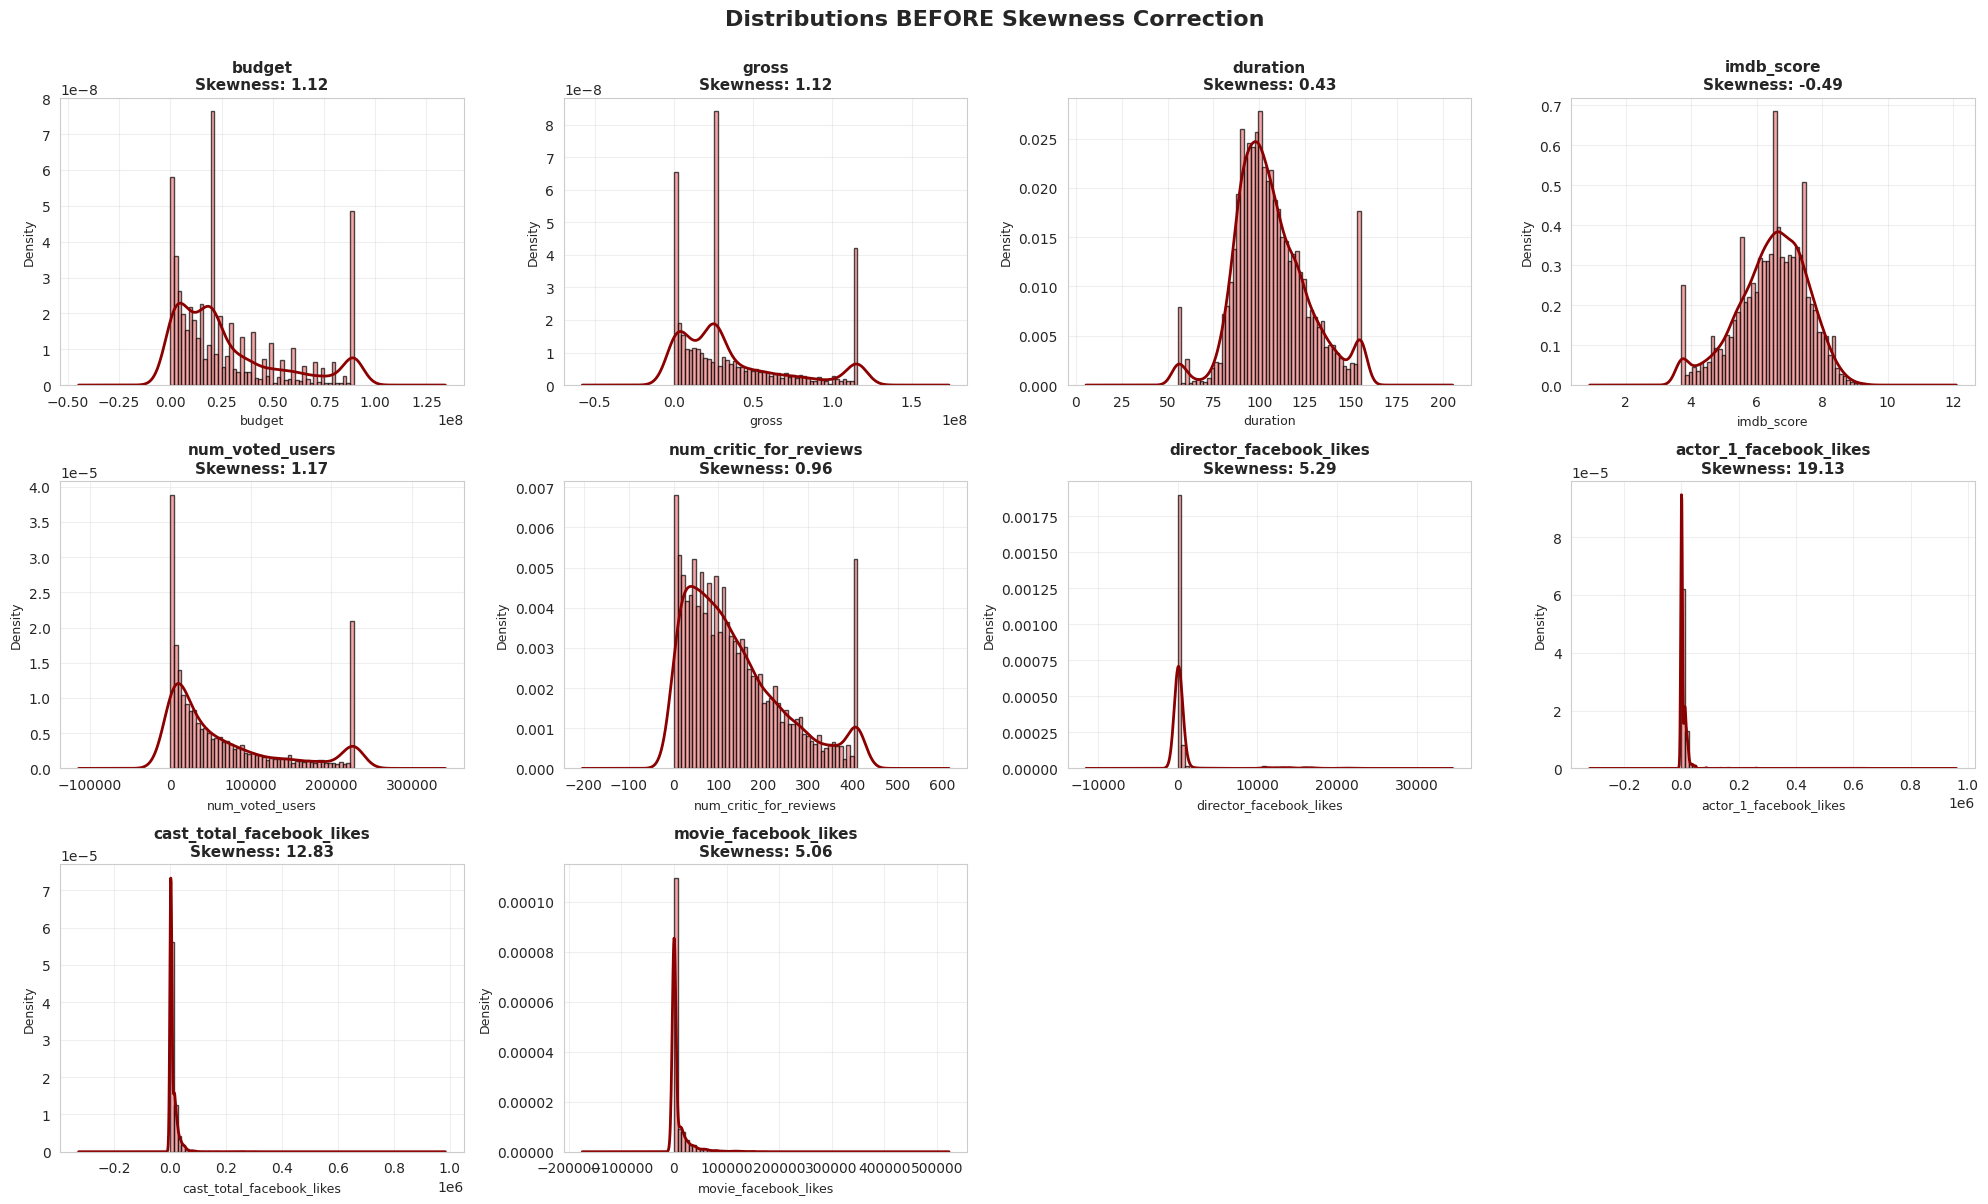

In [7]:
# Visualize distributions BEFORE transformation
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    if idx < len(axes):
        # Histogram + KDE
        axes[idx].hist(df[col].dropna(), bins=50, color='lightcoral',
                      alpha=0.7, density=True, edgecolor='black')
        df[col].dropna().plot(kind='kde', ax=axes[idx], color='darkred', linewidth=2)

        axes[idx].set_title(f'{col}\nSkewness: {df[col].skew():.2f}',
                           fontsize=11, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=9)
        axes[idx].set_ylabel('Density', fontsize=9)
        axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(numeric_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Distributions BEFORE Skewness Correction',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


Prior to any data transformations, this cell visualizes the distributions of the numeric features. Histograms combined with Kernel Density Estimates (KDEs) are used to graphically represent the data's spread. This visual assessment serves to confirm the presence and nature of skewness observed in the quantitative analysis.

## 3. Fixing Skewness with Transformations

In [8]:
# Create a copy for transformations
df_transformed = df.copy()

# Create datasets for different transformations
df_log = df[numeric_features].copy()
df_sqrt = df[numeric_features].copy()
df_boxcox = df[numeric_features].copy()
df_yeojohnson = df[numeric_features].copy()

print("Applying transformations:\n")

for col in numeric_features:
    print(f"Processing: {col}")

    # Log Transformation (only for positive values)
    if (df[col] > 0).all():
        df_log[col] = np.log1p(df[col])  # log1p = log(1 + x)
        print(f"   Log transformation")
    else:
        df_log[col] = df[col]
        print(f"   Log skipped (non-positive values)")

    # Square Root Transformation
    if (df[col] >= 0).all():
        df_sqrt[col] = np.sqrt(df[col])
        print(f"  ✓ Square root transformation")
    else:
        df_sqrt[col] = df[col]
        print(f"   Square root skipped (negative values)")

    # Box-Cox Transformation (only for positive values)
    try:
        if (df[col] > 0).all():
            pt_boxcox = PowerTransformer(method='box-cox', standardize=False)
            df_boxcox[col] = pt_boxcox.fit_transform(df[[col]]).flatten()
            print(f"  ✓ Box-Cox transformation")
        else:
            df_boxcox[col] = df[col]
            print(f"   Box-Cox skipped (non-positive values)")
    except:
        df_boxcox[col] = df[col]
        print(f"   Box-Cox failed")

    # Yeo-Johnson Transformation (works with negative values)
    try:
        pt_yj = PowerTransformer(method='yeo-johnson', standardize=False)
        df_yeojohnson[col] = pt_yj.fit_transform(df[[col]]).flatten()
        print(f"   Yeo-Johnson transformation")
    except:
        df_yeojohnson[col] = df[col]
        print(f"   Yeo-Johnson failed")

    print()

Applying transformations:

Processing: budget
   Log transformation
  ✓ Square root transformation
  ✓ Box-Cox transformation
   Yeo-Johnson transformation

Processing: gross
   Log transformation
  ✓ Square root transformation
  ✓ Box-Cox transformation
   Yeo-Johnson transformation

Processing: duration
   Log transformation
  ✓ Square root transformation
  ✓ Box-Cox transformation
   Yeo-Johnson transformation

Processing: imdb_score
   Log transformation
  ✓ Square root transformation
  ✓ Box-Cox transformation
   Yeo-Johnson transformation

Processing: num_voted_users
   Log transformation
  ✓ Square root transformation
  ✓ Box-Cox transformation
   Yeo-Johnson transformation

Processing: num_critic_for_reviews
   Log transformation
  ✓ Square root transformation
  ✓ Box-Cox transformation
   Yeo-Johnson transformation

Processing: director_facebook_likes
   Log skipped (non-positive values)
  ✓ Square root transformation
   Box-Cox skipped (non-positive values)
   Yeo-Johnson tra

This cell systematically applies various mathematical transformations to the skewed numeric features. The transformations include Log, Square Root, Box-Cox, and Yeo-Johnson, with the objective of normalizing their distributions and reducing skewness. The process logs which transformation is applied or skipped for each feature, based on data characteristics (e.g., presence of non-positive values).

In [9]:
# Compare skewness after transformations
comparison_data = []
for col in numeric_features:
    comparison_data.append({
        'Feature': col,
        'Original': df[col].skew(),
        'Log': df_log[col].skew(),
        'Sqrt': df_sqrt[col].skew(),
        'Box-Cox': df_boxcox[col].skew(),
        'Yeo-Johnson': df_yeojohnson[col].skew()
    })

skewness_comparison = pd.DataFrame(comparison_data)

print("="*70)
print("SKEWNESS COMPARISON (Before vs After)")
print("="*70)
print(skewness_comparison.to_string(index=False))

SKEWNESS COMPARISON (Before vs After)
                  Feature  Original       Log      Sqrt   Box-Cox  Yeo-Johnson
                   budget  1.121381 -1.525043  0.330141 -0.126198    -0.126197
                    gross  1.117535 -1.765866  0.230175 -0.233469    -0.233466
                 duration  0.430261 -0.326787  0.076950  0.021544     0.020931
               imdb_score -0.486249 -0.913099 -0.732302 -0.049763    -0.043810
          num_voted_users  1.173610 -1.157802  0.492704 -0.138696    -0.138516
   num_critic_for_reviews  0.959783 -1.037366  0.151695 -0.100450    -0.094785
  director_facebook_likes  5.289975  5.289975  4.080060  5.289975     0.004399
   actor_1_facebook_likes 19.131046 19.131046  1.953204 19.131046     0.000030
cast_total_facebook_likes 12.831928 12.831928  1.769672 12.831928     0.020654
     movie_facebook_likes  5.058927  5.058927  2.005664  5.058927     0.090060


Following the application of different transformations, this cell re-calculates the skewness for each numeric feature under every transformation method. A comparative table is then generated, presenting the original skewness alongside the skewness values after Log, Sqrt, Box-Cox, and Yeo-Johnson transformations. This enables a direct assessment of each transformation's effectiveness in mitigating skewness.

In [10]:
# Select best transformation for each feature
print("\n" + "="*70)
print("BEST TRANSFORMATION FOR EACH FEATURE")
print("="*70)

for _, row in skewness_comparison.iterrows():
    transformations = {
        'Original': row['Original'],
        'Log': row['Log'],
        'Sqrt': row['Sqrt'],
        'Box-Cox': row['Box-Cox'],
        'Yeo-Johnson': row['Yeo-Johnson']
    }

    best_method = min(transformations.items(), key=lambda x: abs(x[1]))

    print(f"{row['Feature']:30s}: {best_method[0]:15s} (Skewness: {best_method[1]:7.3f})")

    # Apply best transformation to df_transformed
    if best_method[0] == 'Log':
        df_transformed[row['Feature']] = df_log[row['Feature']]
    elif best_method[0] == 'Sqrt':
        df_transformed[row['Feature']] = df_sqrt[row['Feature']]
    elif best_method[0] == 'Box-Cox':
        df_transformed[row['Feature']] = df_boxcox[row['Feature']]
    elif best_method[0] == 'Yeo-Johnson':
        df_transformed[row['Feature']] = df_yeojohnson[row['Feature']]


BEST TRANSFORMATION FOR EACH FEATURE
budget                        : Yeo-Johnson     (Skewness:  -0.126)
gross                         : Sqrt            (Skewness:   0.230)
duration                      : Yeo-Johnson     (Skewness:   0.021)
imdb_score                    : Yeo-Johnson     (Skewness:  -0.044)
num_voted_users               : Yeo-Johnson     (Skewness:  -0.139)
num_critic_for_reviews        : Yeo-Johnson     (Skewness:  -0.095)
director_facebook_likes       : Yeo-Johnson     (Skewness:   0.004)
actor_1_facebook_likes        : Yeo-Johnson     (Skewness:   0.000)
cast_total_facebook_likes     : Yeo-Johnson     (Skewness:   0.021)
movie_facebook_likes          : Yeo-Johnson     (Skewness:   0.090)


Based on the skewness comparison, this cell identifies and applies the most effective transformation (the one yielding skewness closest to zero) for each numeric feature. The selected transformations are then applied to the `df_transformed` DataFrame, ensuring that the data is optimized for further modeling by having a more symmetric distribution.

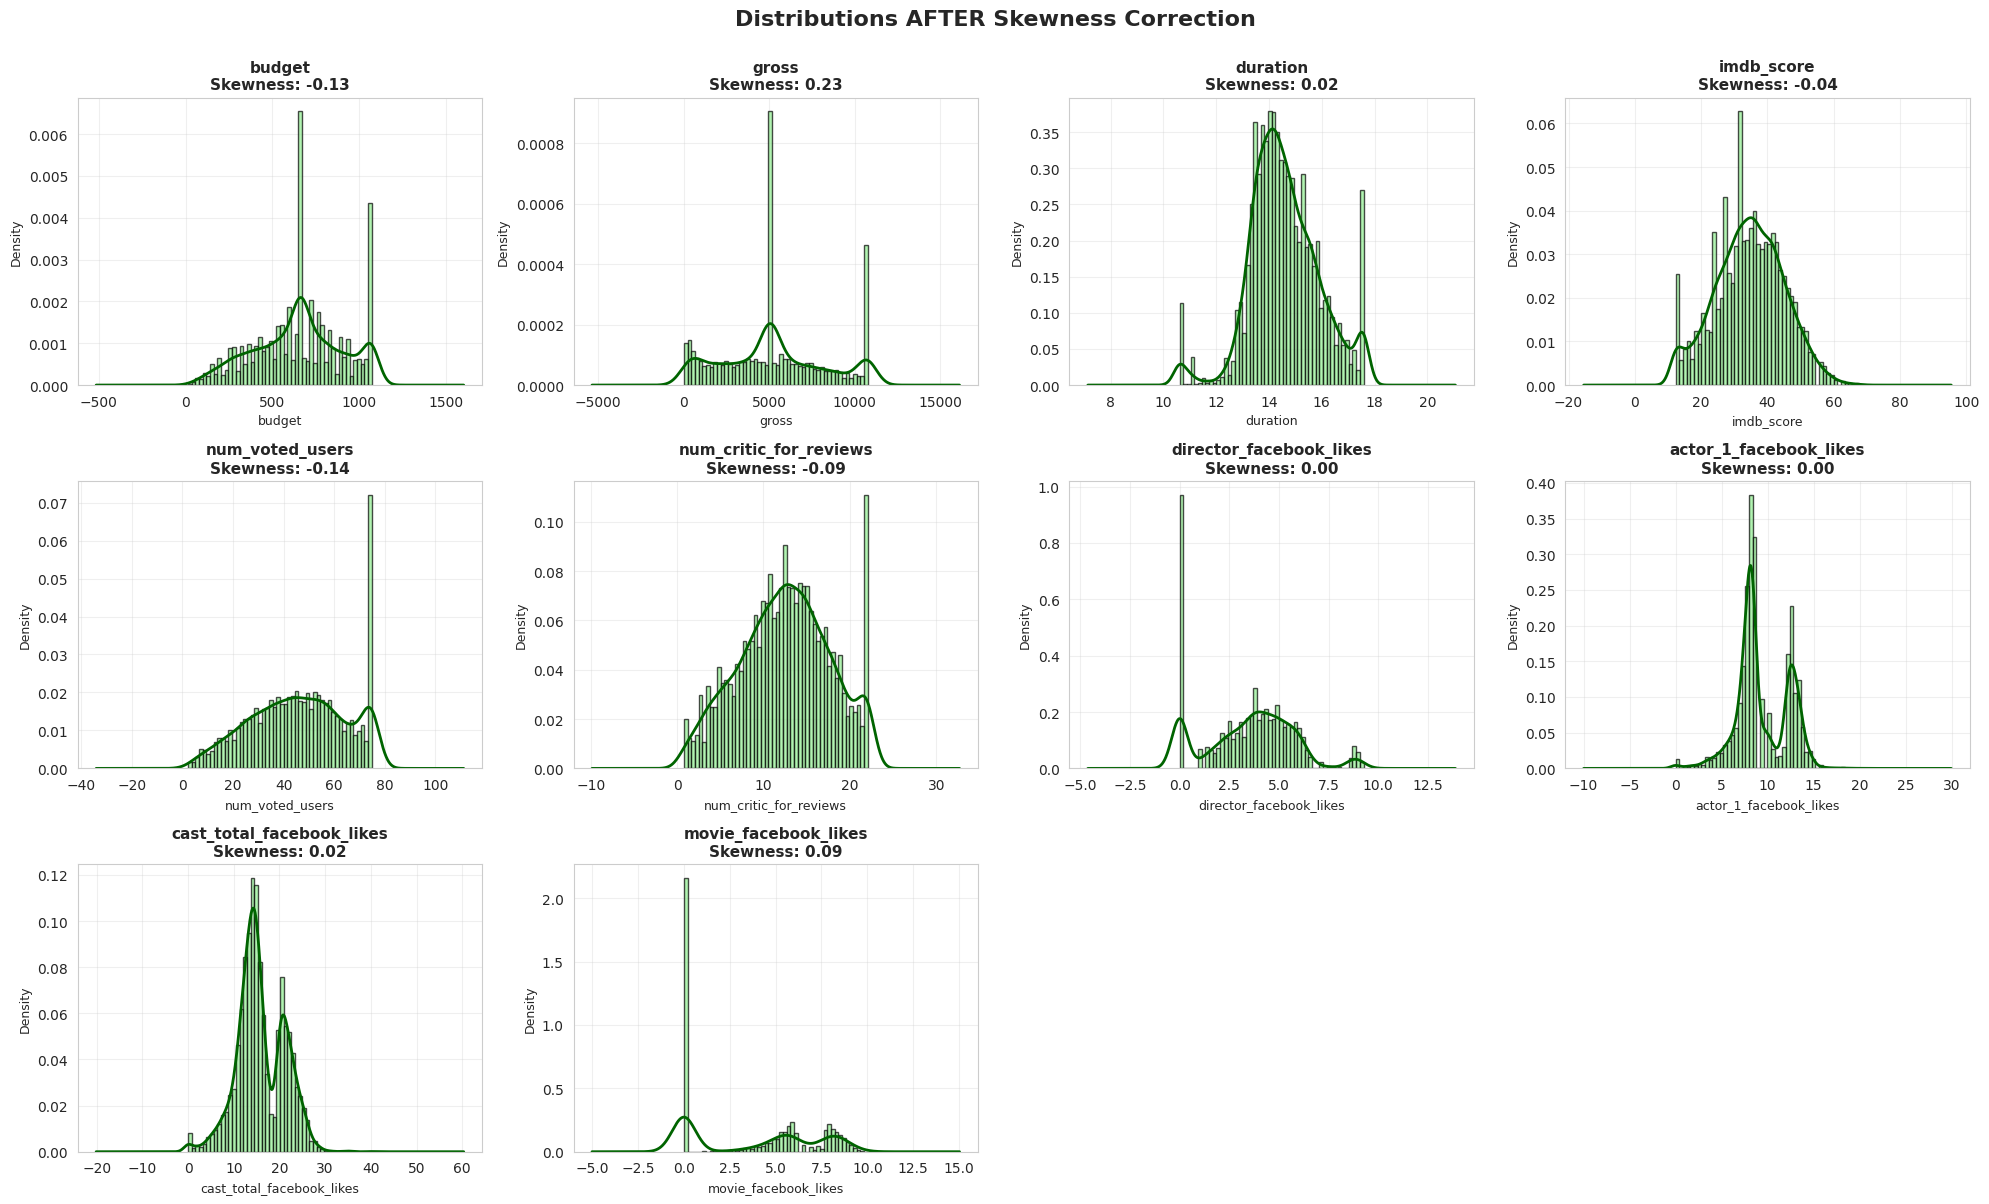

In [11]:
# Visualize distributions AFTER transformation
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    if idx < len(axes):
        # Histogram + KDE
        axes[idx].hist(df_transformed[col].dropna(), bins=50, color='lightgreen',
                      alpha=0.7, density=True, edgecolor='black')
        df_transformed[col].dropna().plot(kind='kde', ax=axes[idx],
                                         color='darkgreen', linewidth=2)

        axes[idx].set_title(f'{col}\nSkewness: {df_transformed[col].skew():.2f}',
                           fontsize=11, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=9)
        axes[idx].set_ylabel('Density', fontsize=9)
        axes[idx].grid(True, alpha=0.3)

for idx in range(len(numeric_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Distributions AFTER Skewness Correction',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

Similar to the pre-transformation visualization, this cell displays the distributions of the numeric features *after* the application of skewness correction. The plots, consisting of histograms and KDEs, are expected to show more symmetric, near-normal distributions, thereby confirming the successful mitigation of skewness.

## 4. Normalization and Scaling

In [12]:
# Select features for scaling demonstration
scaling_features = [col for col in ['budget', 'gross', 'imdb_score', 'duration']
                   if col in df_transformed.columns]

# Create scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

# Apply scalers
df_standard = pd.DataFrame(
    standard_scaler.fit_transform(df_transformed[scaling_features]),
    columns=[f'{col}_standard' for col in scaling_features]
)

df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df_transformed[scaling_features]),
    columns=[f'{col}_minmax' for col in scaling_features]
)

df_robust = pd.DataFrame(
    robust_scaler.fit_transform(df_transformed[scaling_features]),
    columns=[f'{col}_robust' for col in scaling_features]
)

print("="*70)
print("SCALING METHODS APPLIED")
print("="*70)
print("\n1. StandardScaler (Z-score normalization)")
print("   - Mean = 0, Standard Deviation = 1")
print("   - Formula: (x - mean) / std")
print("\n2. MinMaxScaler (Min-Max normalization)")
print("   - Scales to range [0, 1]")
print("   - Formula: (x - min) / (max - min)")
print("\n3. RobustScaler (Robust to outliers)")
print("   - Uses median and IQR")
print("   - Formula: (x - median) / IQR")

SCALING METHODS APPLIED

1. StandardScaler (Z-score normalization)
   - Mean = 0, Standard Deviation = 1
   - Formula: (x - mean) / std

2. MinMaxScaler (Min-Max normalization)
   - Scales to range [0, 1]
   - Formula: (x - min) / (max - min)

3. RobustScaler (Robust to outliers)
   - Uses median and IQR
   - Formula: (x - median) / IQR


This cell demonstrates various data scaling techniques using a selection of numeric features. It applies three common scalers: `StandardScaler` (which standardizes features by removing the mean and scaling to unit variance), `MinMaxScaler` (which scales features to a given range, typically [0, 1]), and `RobustScaler` (which scales features using statistics that are robust to outliers). The purpose is to illustrate how each method alters the data's range and distribution.

In [13]:
# Statistics comparison
print("\n" + "="*70)
print("SCALING STATISTICS COMPARISON")
print("="*70)

for idx, feature in enumerate(scaling_features):
    print(f"\n{feature}:")
    print(f"  Original     -> Mean: {df_transformed[feature].mean():10.2f}, Std: {df_transformed[feature].std():10.2f}, Min: {df_transformed[feature].min():10.2f}, Max: {df_transformed[feature].max():10.2f}")
    print(f"  Standard     -> Mean: {df_standard.iloc[:, idx].mean():10.2f}, Std: {df_standard.iloc[:, idx].std():10.2f}, Min: {df_standard.iloc[:, idx].min():10.2f}, Max: {df_standard.iloc[:, idx].max():10.2f}")
    print(f"  MinMax       -> Mean: {df_minmax.iloc[:, idx].mean():10.2f}, Std: {df_minmax.iloc[:, idx].std():10.2f}, Min: {df_minmax.iloc[:, idx].min():10.2f}, Max: {df_minmax.iloc[:, idx].max():10.2f}")
    print(f"  Robust       -> Mean: {df_robust.iloc[:, idx].mean():10.2f}, Std: {df_robust.iloc[:, idx].std():10.2f}, Min: {df_robust.iloc[:, idx].min():10.2f}, Max: {df_robust.iloc[:, idx].max():10.2f}")


SCALING STATISTICS COMPARISON

budget:
  Original     -> Mean:     652.80, Std:     252.68, Min:      14.35, Max:    1073.62
  Standard     -> Mean:       0.00, Std:       1.00, Min:      -2.53, Max:       1.67
  MinMax       -> Mean:       0.60, Std:       0.24, Min:       0.00, Max:       1.00
  Robust       -> Mean:      -0.03, Std:       0.71, Min:      -1.83, Max:       1.15

gross:
  Original     -> Mean:    5198.23, Std:    3080.10, Min:      12.73, Max:   10756.45
  Standard     -> Mean:      -0.00, Std:       1.00, Min:      -1.68, Max:       1.80
  MinMax       -> Mean:       0.48, Std:       0.29, Min:       0.00, Max:       1.00
  Robust       -> Mean:       0.03, Std:       0.72, Min:      -1.18, Max:       1.34

imdb_score:
  Original     -> Mean:      34.62, Std:      10.24, Min:      12.30, Max:      67.75
  Standard     -> Mean:       0.00, Std:       1.00, Min:      -2.18, Max:       3.24
  MinMax       -> Mean:       0.40, Std:       0.18, Min:       0.00, Max:     

After applying the various scaling methods, this cell provides a statistical comparison. It outputs the mean, standard deviation, minimum, and maximum values for the selected features, both in their original state and after being processed by `StandardScaler`, `MinMaxScaler`, and `RobustScaler`. This quantitative summary highlights the effects of each scaling technique on the data's statistical properties.

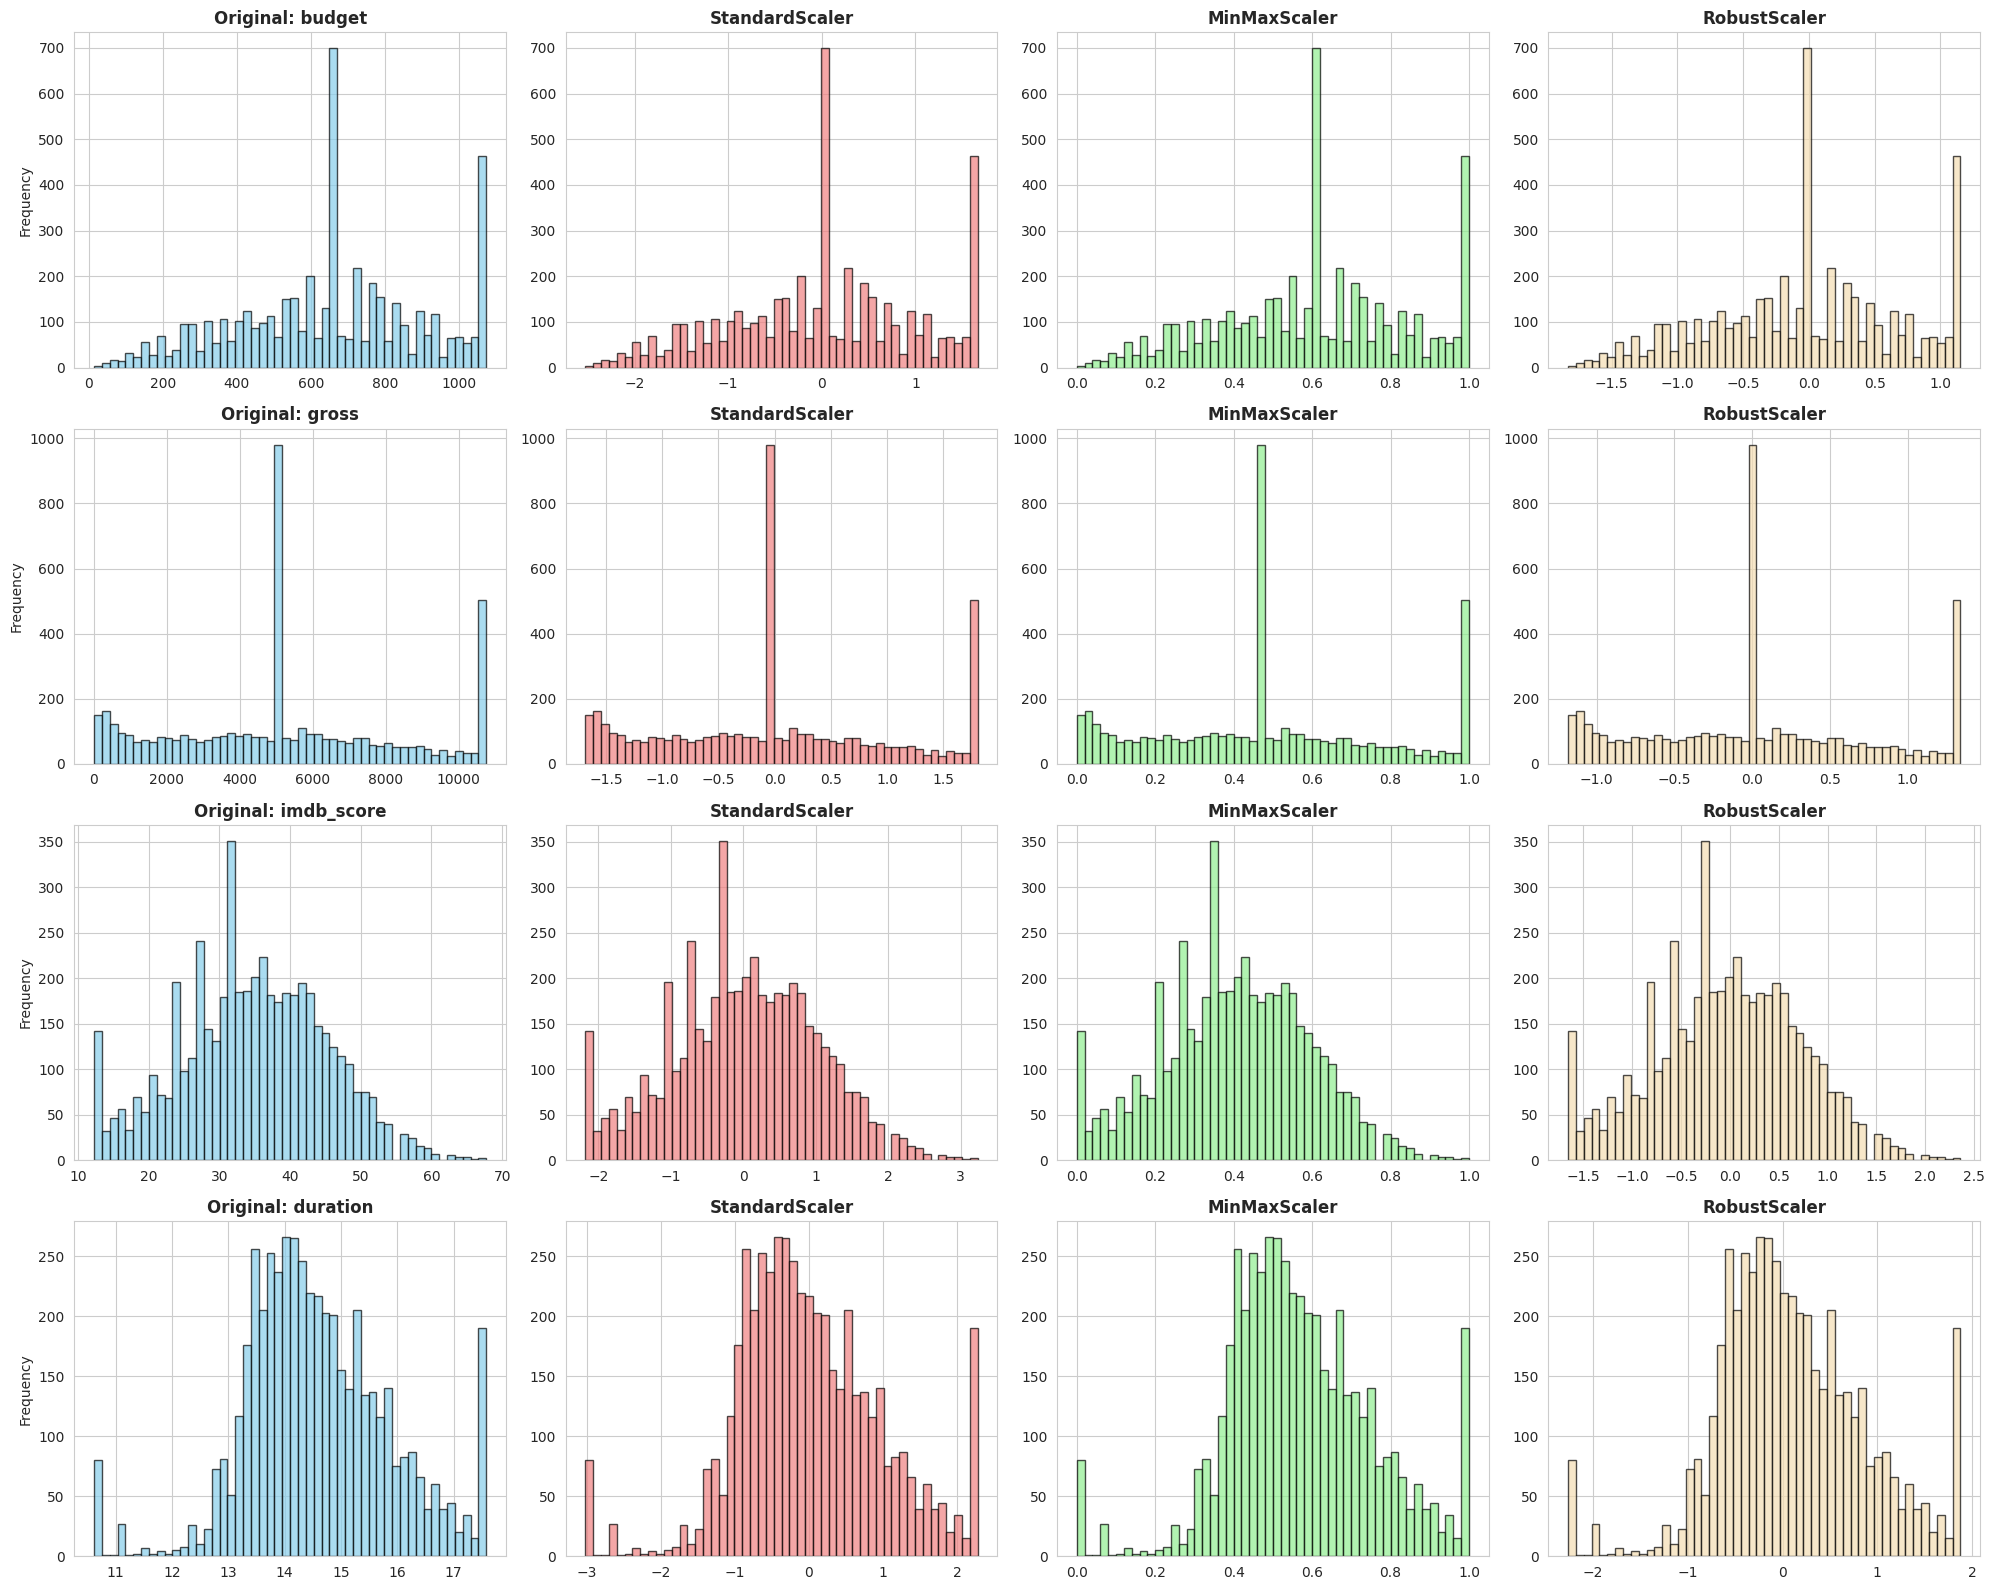

In [14]:
# Visualize scaling effects
fig, axes = plt.subplots(len(scaling_features), 4, figsize=(20, 4*len(scaling_features)))

for idx, feature in enumerate(scaling_features):
    # Original
    axes[idx, 0].hist(df_transformed[feature].dropna(), bins=50,
                     color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'Original: {feature}', fontweight='bold')
    axes[idx, 0].set_ylabel('Frequency')

    # StandardScaler
    axes[idx, 1].hist(df_standard.iloc[:, idx].dropna(), bins=50,
                     color='lightcoral', edgecolor='black', alpha=0.7)
    axes[idx, 1].set_title(f'StandardScaler', fontweight='bold')

    # MinMaxScaler
    axes[idx, 2].hist(df_minmax.iloc[:, idx].dropna(), bins=50,
                     color='lightgreen', edgecolor='black', alpha=0.7)
    axes[idx, 2].set_title(f'MinMaxScaler', fontweight='bold')

    # RobustScaler
    axes[idx, 3].hist(df_robust.iloc[:, idx].dropna(), bins=50,
                     color='wheat', edgecolor='black', alpha=0.7)
    axes[idx, 3].set_title(f'RobustScaler', fontweight='bold')

plt.tight_layout()
plt.show()


This cell visually represents the impact of data scaling through histograms. It displays the distributions of the original features alongside their scaled versions from `StandardScaler`, `MinMaxScaler`, and `RobustScaler`. The visualization clearly illustrates how each scaler adjusts the range and spread of the data while preserving the fundamental shape of its distribution.

In [15]:
# Apply StandardScaler to all numeric features for final dataset
print("\nApplying StandardScaler to all numeric features:")
scaler_final = StandardScaler()
df_transformed[numeric_features] = scaler_final.fit_transform(df_transformed[numeric_features])
print(" StandardScaler applied to all numeric features")


Applying StandardScaler to all numeric features:
 StandardScaler applied to all numeric features


This cell applies `StandardScaler` to all numeric features within the `df_transformed` DataFrame. The `StandardScaler` transforms the data such that each feature has a mean of 0 and a standard deviation of 1. This standardization is a crucial preprocessing step, ensuring that all numerical features contribute equally to subsequent machine learning models.

## 5. Encoding Categorical Variables

In [16]:
# Select categorical features
categorical_features = ['color', 'director_name', 'content_rating', 'language', 'country']
categorical_features = [col for col in categorical_features if col in df.columns]

print("="*70)
print("CATEGORICAL VARIABLES OVERVIEW")
print("="*70)

for col in categorical_features:
    unique_count = df[col].nunique()
    print(f"\n{col}:")
    print(f"  Unique values: {unique_count}")
    print(f"  Top 5: {df[col].value_counts().head().to_dict()}")

CATEGORICAL VARIABLES OVERVIEW

color:
  Unique values: 2
  Top 5: {'Color': 4834, ' Black and White': 209}

director_name:
  Unique values: 2398
  Top 5: {'Steven Spielberg': 130, 'Woody Allen': 22, 'Martin Scorsese': 20, 'Clint Eastwood': 20, 'Ridley Scott': 17}

content_rating:
  Unique values: 18
  Top 5: {'R': 2421, 'PG-13': 1461, 'PG': 701, 'Not Rated': 116, 'G': 112}

language:
  Unique values: 46
  Top 5: {'English': 4718, 'French': 73, 'Spanish': 40, 'Hindi': 28, 'Mandarin': 26}

country:
  Unique values: 65
  Top 5: {'USA': 3812, 'UK': 448, 'France': 154, 'Canada': 126, 'Germany': 97}


This section introduces the processing of categorical variables. It identifies key categorical features, such as 'color', 'director_name', 'content_rating', 'language', and 'country'. For each identified feature, it provides an overview, including the count of unique values and the top five most frequent categories, to characterize their distribution and cardinality.

### 5.1 Label Encoding (for ordinal variables)

In [17]:
print("="*70)
print("LABEL ENCODING")
print("="*70)
print("Best for: Ordinal categorical variables (with order)\n")

# Apply Label Encoding to color
if 'color' in df.columns:
    label_encoder_color = LabelEncoder()
    df_transformed['color_encoded'] = label_encoder_color.fit_transform(
        df['color'].astype(str)
    )

    print("Label Encoding for 'color':")
    encoding_map = dict(zip(label_encoder_color.classes_,
                           label_encoder_color.transform(label_encoder_color.classes_)))
    for key, value in encoding_map.items():
        print(f"  {key:15s} -> {value}")
    print()

# Apply Label Encoding to content_rating
if 'content_rating' in df.columns:
    label_encoder_rating = LabelEncoder()
    df_transformed['content_rating_encoded'] = label_encoder_rating.fit_transform(
        df['content_rating'].astype(str)
    )

    print("Label Encoding for 'content_rating':")
    encoding_map = dict(zip(label_encoder_rating.classes_,
                           label_encoder_rating.transform(label_encoder_rating.classes_)))
    for key, value in sorted(encoding_map.items(), key=lambda x: x[1]):
        print(f"  {key:15s} -> {value}")

LABEL ENCODING
Best for: Ordinal categorical variables (with order)

Label Encoding for 'color':
   Black and White -> 0
  Color           -> 1

Label Encoding for 'content_rating':
  Approved        -> 0
  G               -> 1
  GP              -> 2
  M               -> 3
  NC-17           -> 4
  Not Rated       -> 5
  PG              -> 6
  PG-13           -> 7
  Passed          -> 8
  R               -> 9
  TV-14           -> 10
  TV-G            -> 11
  TV-MA           -> 12
  TV-PG           -> 13
  TV-Y            -> 14
  TV-Y7           -> 15
  Unrated         -> 16
  X               -> 17


This cell performs Label Encoding on the 'color' and 'content_rating' categorical features. Label encoding assigns a unique integer to each distinct category within a feature. For 'color', it maps 'Black and White' to 0 and 'Color' to 1. For 'content_rating', it provides a numerical representation for each rating category, facilitating their use in numerical models.

### 5.2 One-Hot Encoding (for nominal variables)

In [18]:
print("\n" + "="*70)
print("ONE-HOT ENCODING")
print("="*70)
print("Best for: Nominal categorical variables (no order)\n")

# One-Hot Encoding for language (top 5)
if 'language' in df.columns:
    top_languages = df['language'].value_counts().head(5).index
    df_language_filtered = df['language'].apply(
        lambda x: x if x in top_languages else 'Other'
    )

    language_dummies = pd.get_dummies(df_language_filtered, prefix='language')
    df_transformed = pd.concat([df_transformed, language_dummies], axis=1)

    print(f"One-Hot Encoding for 'language' (Top 5 + Other):")
    print(f"  Created {len(language_dummies.columns)} binary columns")
    print(f"  Columns: {list(language_dummies.columns)}")
    print()

# One-Hot Encoding for country (top 5)
if 'country' in df.columns:
    top_countries = df['country'].value_counts().head(5).index
    df_country_filtered = df['country'].apply(
        lambda x: x if x in top_countries else 'Other'
    )

    country_dummies = pd.get_dummies(df_country_filtered, prefix='country')
    df_transformed = pd.concat([df_transformed, country_dummies], axis=1)

    print(f"One-Hot Encoding for 'country' (Top 5 + Other):")
    print(f"  Created {len(country_dummies.columns)} binary columns")
    print(f"  Columns: {list(country_dummies.columns)}")


ONE-HOT ENCODING
Best for: Nominal categorical variables (no order)

One-Hot Encoding for 'language' (Top 5 + Other):
  Created 6 binary columns
  Columns: ['language_English', 'language_French', 'language_Hindi', 'language_Mandarin', 'language_Other', 'language_Spanish']

One-Hot Encoding for 'country' (Top 5 + Other):
  Created 6 binary columns
  Columns: ['country_Canada', 'country_France', 'country_Germany', 'country_Other', 'country_UK', 'country_USA']


This cell implements One-Hot Encoding for the 'language' and 'country' features. For each feature, it identifies the top five most frequent categories and groups all other categories into an 'Other' category. One-Hot Encoding then converts these categories into binary (0 or 1) columns, creating new columns for each top category and for 'Other', which is suitable for nominal categorical data without inherent order.

### 5.3 Frequency Encoding (for high-cardinality variables)

In [19]:
print("\n" + "="*70)
print("FREQUENCY ENCODING")
print("="*70)
print("Best for: High-cardinality categorical variables\n")

# Frequency Encoding for director_name
if 'director_name' in df.columns:
    freq_encoding = df['director_name'].value_counts(normalize=True).to_dict()
    df_transformed['director_frequency'] = df['director_name'].map(freq_encoding)

    print("Frequency Encoding for 'director_name':")
    print(f"  Unique directors: {df['director_name'].nunique()}")
    print(f"  Top 5 directors by frequency:")
    for director, freq in list(freq_encoding.items())[:5]:
        print(f"    {director:30s}: {freq:.4f}")


FREQUENCY ENCODING
Best for: High-cardinality categorical variables

Frequency Encoding for 'director_name':
  Unique directors: 2398
  Top 5 directors by frequency:
    Steven Spielberg              : 0.0258
    Woody Allen                   : 0.0044
    Martin Scorsese               : 0.0040
    Clint Eastwood                : 0.0040
    Ridley Scott                  : 0.0034


For the high-cardinality feature 'director_name', this cell applies Frequency Encoding. This method replaces each categorical value with its occurrence frequency within the dataset. This approach is beneficial for features with a large number of unique values, as it represents categorical information numerically without generating a vast number of new columns.

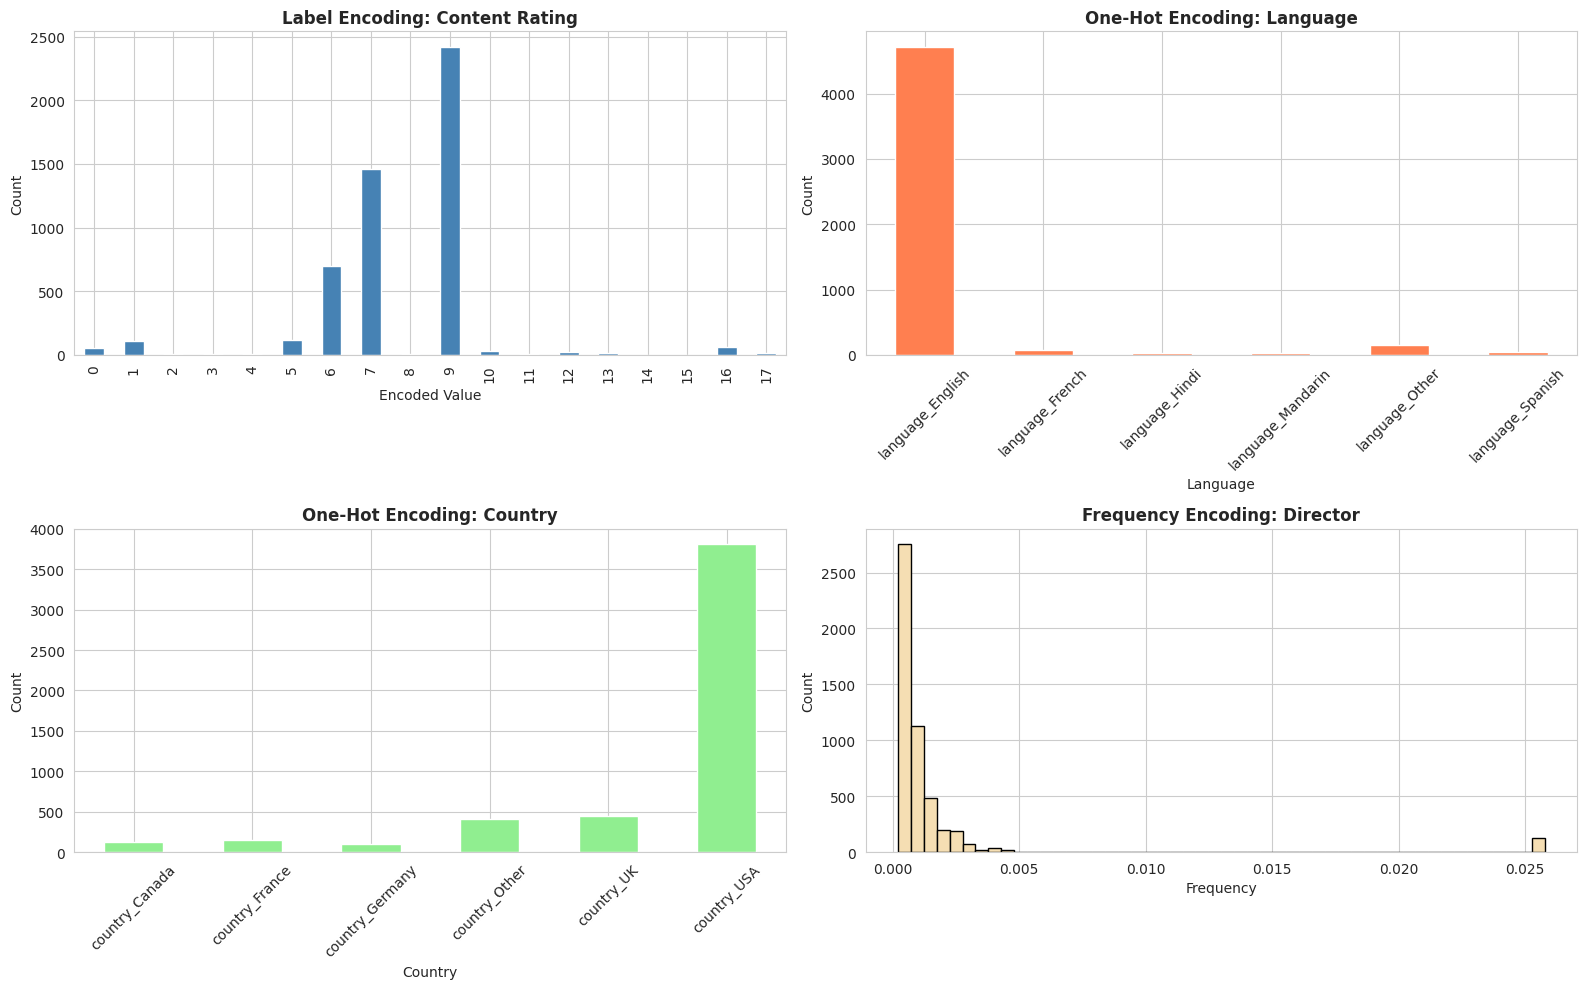

In [20]:
# Visualize encoding effects
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Label Encoding (content_rating)
if 'content_rating_encoded' in df_transformed.columns:
    df_transformed['content_rating_encoded'].value_counts().sort_index().plot(
        kind='bar', ax=axes[0, 0], color='steelblue'
    )
    axes[0, 0].set_title('Label Encoding: Content Rating', fontweight='bold', fontsize=12)
    axes[0, 0].set_xlabel('Encoded Value')
    axes[0, 0].set_ylabel('Count')

# Plot 2: One-Hot Encoding (language)
if 'language' in df.columns:
    language_cols = [col for col in df_transformed.columns if col.startswith('language_')]
    if language_cols:
        df_transformed[language_cols].sum().plot(kind='bar', ax=axes[0, 1], color='coral')
        axes[0, 1].set_title('One-Hot Encoding: Language', fontweight='bold', fontsize=12)
        axes[0, 1].set_xlabel('Language')
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: One-Hot Encoding (country)
if 'country' in df.columns:
    country_cols = [col for col in df_transformed.columns if col.startswith('country_')]
    if country_cols:
        df_transformed[country_cols].sum().plot(kind='bar', ax=axes[1, 0], color='lightgreen')
        axes[1, 0].set_title('One-Hot Encoding: Country', fontweight='bold', fontsize=12)
        axes[1, 0].set_xlabel('Country')
        axes[1, 0].set_ylabel('Count')
        axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Frequency Encoding (director)
if 'director_frequency' in df_transformed.columns:
    axes[1, 1].hist(df_transformed['director_frequency'].dropna(), bins=50,
                   color='wheat', edgecolor='black')
    axes[1, 1].set_title('Frequency Encoding: Director', fontweight='bold', fontsize=12)
    axes[1, 1].set_xlabel('Frequency')
    axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()


This cell visualizes the outcomes of the categorical encoding processes. It generates bar plots for the label-encoded 'content_rating', and for the one-hot encoded 'language' and 'country' features to show their distributions. For the frequency-encoded 'director_frequency', a histogram is used to illustrate the distribution of frequencies, verifying the correct application of each encoding method.

## 6. Save Feature Engineered Dataset

In [21]:
# Save the transformed dataset
df_transformed.to_csv('movie_metadata_feature_engineered.csv', index=False)

print("="*70)
print("FEATURE ENGINEERING COMPLETE!")
print("="*70)
print(f"\nOriginal Dataset Shape: {df.shape}")
print(f"Transformed Dataset Shape: {df_transformed.shape}")
print(f"New Features Created: {df_transformed.shape[1] - df.shape[1]}")
print(f"\nOutput Files:")
print("  1. week6_skewness_before.png")
print("  2. week6_skewness_after.png")
print("  3. week6_scaling_comparison.png")
print("  4. week6_encoding_visualization.png")
print("  5. movie_metadata_feature_engineered.csv")

FEATURE ENGINEERING COMPLETE!

Original Dataset Shape: (5043, 28)
Transformed Dataset Shape: (5043, 43)
New Features Created: 15

Output Files:
  1. week6_skewness_before.png
  2. week6_skewness_after.png
  3. week6_scaling_comparison.png
  4. week6_encoding_visualization.png
  5. movie_metadata_feature_engineered.csv


This cell concludes the feature engineering process by saving the `df_transformed` DataFrame, which now incorporates all the skewness-corrected, scaled, and encoded features, into a new CSV file named `movie_metadata_feature_engineered.csv`. It also provides a summary, including the original and transformed dataset shapes, the number of new features created, and a list of all output files.

## 7. Summary Statistics

In [23]:
print("="*70)
print("SUMMARY REPORT")
print("="*70)

print("\n SKEWNESS CORRECTION")
print("-" * 70)
print(f"Features Analyzed: {len(numeric_features)}")
print(f"Average Skewness Before: {skewness_before['Skewness'].abs().mean():.3f}")
skewness_after = [df_transformed[col].skew() for col in numeric_features]
print(f"Average Skewness After: {np.mean(np.abs(skewness_after)):.3f}")
improvement = ((skewness_before['Skewness'].abs().mean() - np.mean(np.abs(skewness_after))) /
               skewness_before['Skewness'].abs().mean() * 100)
print(f"Improvement: {improvement:.1f}%")

print("\n SCALING")
print("-" * 70)
print(f"Scaler Used: StandardScaler")
print(f"Features Scaled: {len(numeric_features)}")

print("\n ENCODING")
print("-" * 70)
print("Label Encoded: content_rating, color")
print("One-Hot Encoded: language (top 5), country (top 5)")
print("Frequency Encoded: director_name")

print("\n" + "="*70)


SUMMARY REPORT

 SKEWNESS CORRECTION
----------------------------------------------------------------------
Features Analyzed: 10
Average Skewness Before: 4.760
Average Skewness After: 0.077
Improvement: 98.4%

 SCALING
----------------------------------------------------------------------
Scaler Used: StandardScaler
Features Scaled: 10

 ENCODING
----------------------------------------------------------------------
Label Encoded: content_rating, color
One-Hot Encoded: language (top 5), country (top 5)
Frequency Encoded: director_name



This final cell presents a comprehensive summary report of the feature engineering steps performed. It details the improvement in skewness correction, specifies the scaling method applied, and lists the categorical features processed by Label Encoding, One-Hot Encoding, and Frequency Encoding. This report serves as a concise overview of the data preparation efforts undertaken.